# Load and Prepare the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving E1.csv to E1 (2).csv


In [ ]:
df = pd.read_csv("E1.csv")

In [ ]:
df = df.rename(columns={
    "B365>2.5": "B365O2_5",
    "B365<2.5": "B365U2_5"
})

# Convert date column

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# convert odds → probabilities:

In [ ]:
df["p_over25"] = 1 / df["B365O2_5"]
df["p_under25"] = 1 / df["B365U2_5"]

total = df["p_over25"] + df["p_under25"]

df["p_over25"] /= total
df["p_under25"] /= total

In [ ]:
df["total_goals"] = df["FTHG"] + df["FTAG"]

# Actual Outcome Encoding

In [ ]:
df["actual_over25"] = (df["total_goals"] > 2.5).astype(int)
df["actual_under25"] = (df["total_goals"] <= 2.5).astype(int)

In [ ]:
df["over25_overperf"] = df["actual_over25"] - df["p_over25"]
df["under25_overperf"] = df["actual_under25"] - df["p_under25"]

In [ ]:
home = df.groupby("HomeTeam")["over25_overperf"].mean()
away = df.groupby("AwayTeam")["under25_overperf"].mean()

In [ ]:
team_overperf = home + away
team_overperf = team_overperf.sort_values(ascending=False)

# Is the market pricing this team's home strength correctly?

In [ ]:
team_calibration = df.groupby("HomeTeam").agg(

    # Average bookmaker expectation
    expected_over25_prob=("p_over25", "mean"),

    # Actual over 2.5 rate
    actual_over25_rate=("actual_over25", "mean"),

    # Number of matches
    matches=("actual_over25", "count")

).reset_index()

In [ ]:
team_calibration["market_efficiency_score"] = (
    team_calibration["actual_over25_rate"] -
    team_calibration["expected_over25_prob"]
)

In [ ]:
team_calibration["expected_over25_prob"] = (
    team_calibration["expected_over25_prob"] * 100
).round(1)

team_calibration["actual_over25_rate"] = (
    team_calibration["actual_over25_rate"] * 100
).round(1)

team_calibration["market_efficiency_score"] = (
    team_calibration["market_efficiency_score"]
).round(3)

In [ ]:
team_calibration.head(50)

,HomeTeam,expected_over25_prob,actual_over25_rate,matches,market_efficiency_score
0,Birmingham,48.0,47.8,23,-0.001
1,Blackburn,45.0,30.4,23,-0.145
2,Bristol City,49.5,47.8,23,-0.016
3,Charlton,43.8,43.5,23,-0.003
4,Coventry,55.3,65.2,23,0.099
5,Derby,43.8,39.1,23,-0.046
6,Hull,49.7,60.9,23,0.112
7,Ipswich,52.1,56.5,23,0.044
8,Leicester,50.1,52.2,23,0.021
9,Middlesbrough,51.9,43.5,23,-0.084


In [ ]:
team_overperf.head(10)

,0
HomeTeam,
QPR,0.312810
Sheffield United,0.291045
Stoke,0.266277
Wrexham,0.134134
Charlton,0.102993
Millwall,0.087926
Ipswich,0.048418
Swansea,0.043055
Bristol City,0.033500


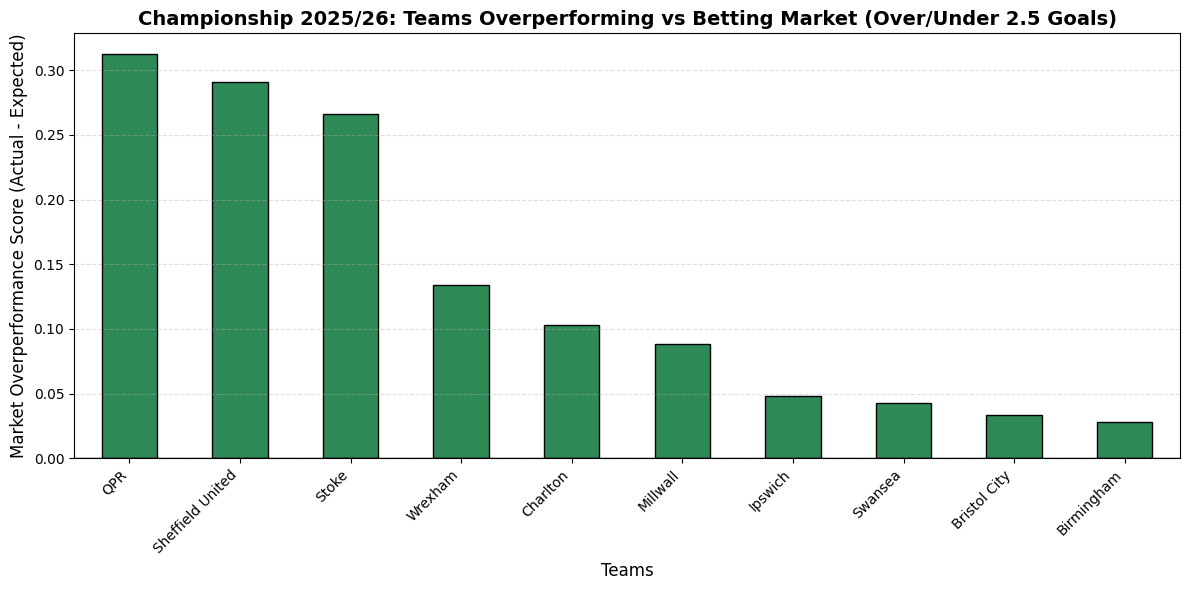

In [ ]:
import matplotlib.pyplot as plt

# Top 10 overperforming teams
top_over = team_overperf.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

# Bar plot with better styling
bars = top_over.plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

# Title (more analytical framing)
plt.title(
    "Championship 2025/26: Teams Overperforming vs Betting Market (Over/Under 2.5 Goals)",
    fontsize=14,
    fontweight="bold"
)

# Axis labels (clearer interpretation)
plt.xlabel("Teams", fontsize=12)
plt.ylabel("Market Overperformance Score (Actual - Expected)", fontsize=12)

# Improve readability
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add horizontal reference line (very important for storytelling)
plt.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
team_overperf.tail(10)

,0
HomeTeam,
West Brom,-0.044429
Leicester,-0.054747
Portsmouth,-0.076880
Hull,-0.081734
Watford,-0.086347
Norwich,-0.098350
Blackburn,-0.166200
Southampton,-0.230051
Middlesbrough,-0.242203


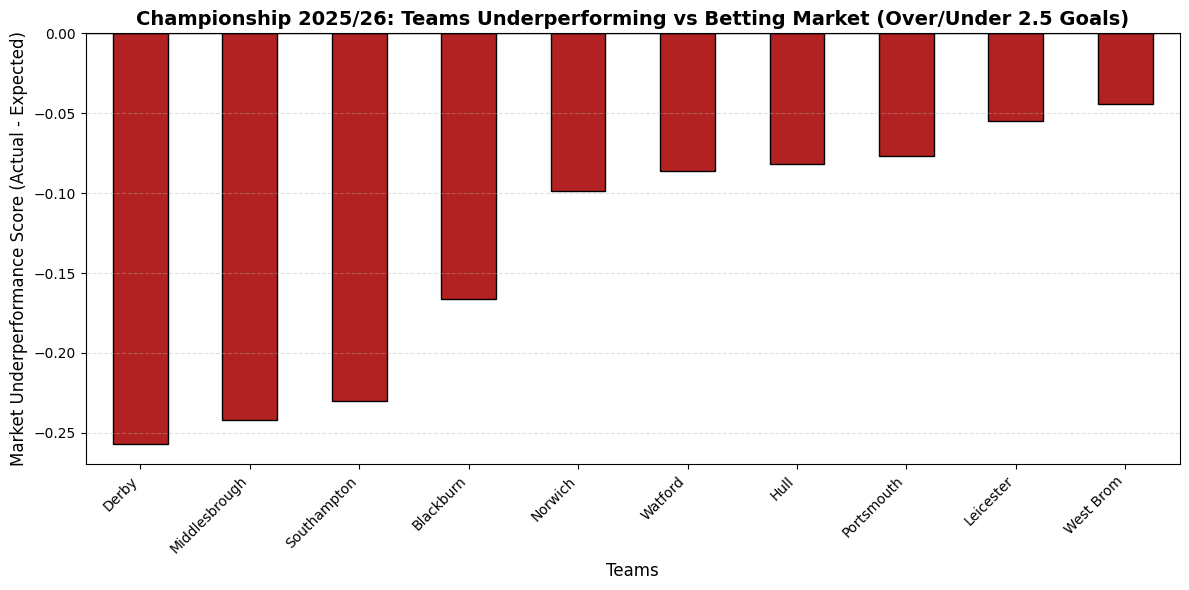

In [ ]:
import matplotlib.pyplot as plt

# Bottom 10 underperforming teams
bottom_over = team_overperf.sort_values(ascending=True).head(10)

plt.figure(figsize=(12, 6))

# Bar plot with stronger visual meaning
bars = bottom_over.plot(
    kind="bar",
    color="firebrick",
    edgecolor="black"
)

# Title (more analytical framing)
plt.title(
    "Championship 2025/26: Teams Underperforming vs Betting Market (Over/Under 2.5 Goals)",
    fontsize=14,
    fontweight="bold"
)

# Axis labels (clear interpretation)
plt.xlabel("Teams", fontsize=12)
plt.ylabel("Market Underperformance Score (Actual - Expected)", fontsize=12)

# Improve readability
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add reference line (VERY important for storytelling)
plt.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

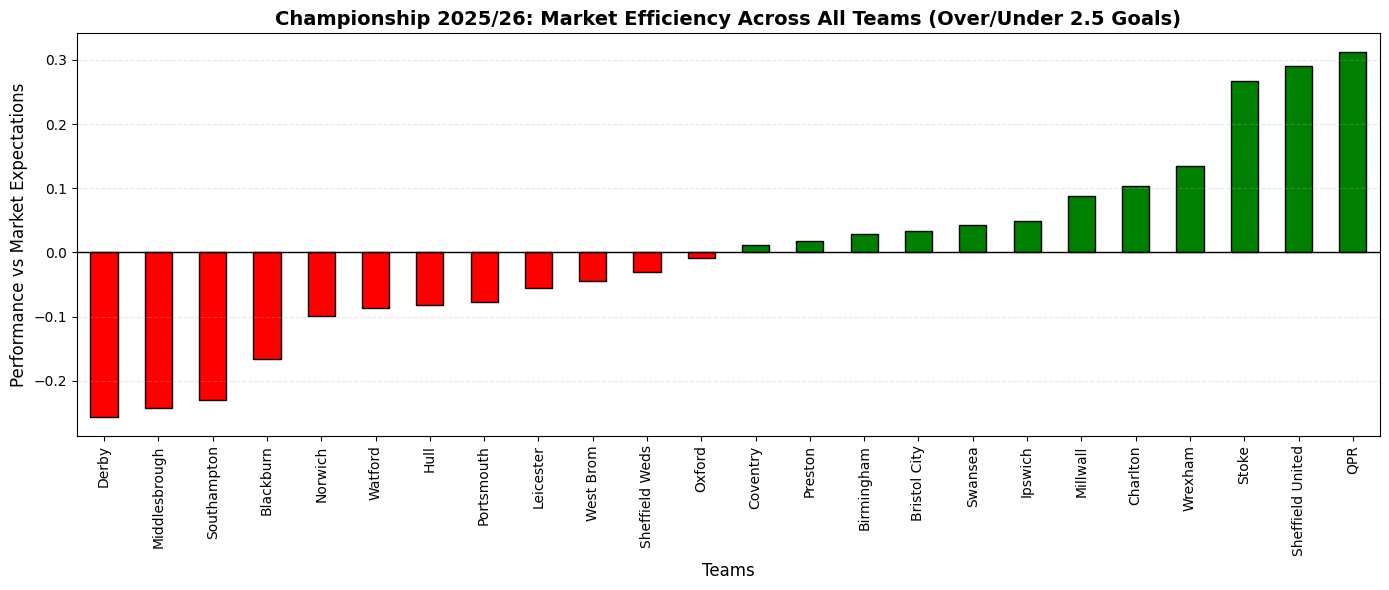

In [ ]:
import matplotlib.pyplot as plt

# Sort values
team_sorted = team_overperf.sort_values()

plt.figure(figsize=(14, 6))

# Color logic: red for underperforming, green for overperforming
colors = ["red" if x < 0 else "green" for x in team_sorted]

team_sorted.plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)

# Title (more analytical framing)
plt.title(
    "Championship 2025/26: Market Efficiency Across All Teams (Over/Under 2.5 Goals)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Teams", fontsize=12)
plt.ylabel("Performance vs Market Expectations", fontsize=12)

# Key reference line (VERY important)
plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()